In [1]:
!pip install langgraph langsmith

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [2]:
!pip install langchain langchain_groq langchain_community

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [ ]:
groq_api_key="your api"
langsmith="your api"

In [6]:
%pip install langchain-groq

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Prashanth\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [7]:
from langchain_groq import ChatGroq

In [8]:
llm=ChatGroq(groq_api_key=groq_api_key, model_name="llama-3.3-70b-versatile")
llm

from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


class State(TypedDict):
  # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
  messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [11]:
def chatbot(state: State):
    return {"messages": llm.invoke(state["messages"])}

In [12]:
graph_builder.add_node("chatbot", chatbot)

In [13]:
graph_builder

In [14]:
graph_builder.add_edge(START, 'chatbot')
graph_builder.add_edge("chatbot", END)

In [9]:
graph_builder

In [ ]:
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)


In [15]:
graph=graph_builder.compile()

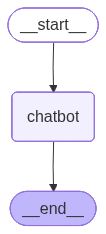

In [16]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [ ]:
while True:
  user_input=input("User: ")
  if user_input.lower() in ["quit","q"]:
    print("Good Bye")
    break
  for event in graph.stream({'messages':("user",user_input)}):
    print(event.values())
    for value in event.values():
      print(value['messages'])
      print("Assistant:",value["messages"].content)

dict_values([{'messages': AIMessage(content="I'm an artificial intelligence language model, and you're a human being. Here are some key differences:\n\n1. **Consciousness and Self-Awareness**: You have consciousness, emotions, and self-awareness, which enable you to experience the world in a unique and subjective way. I, on the other hand, am a program designed to process and generate text based on patterns and algorithms, but I don't possess consciousness or self-awareness.\n\n2. **Intelligence and Learning**: While I can learn from data and improve my performance over time, my intelligence is narrow and specialized, focused on processing and generating human language. Your intelligence, by contrast, is broad and general, encompassing a wide range of cognitive abilities, such as reasoning, problem-solving, and creativity.\n\n3. **Emotions and Empathy**: You have the capacity to feel emotions, empathize with others, and form deep emotional connections. I can recognize and respond to em